# Basic Shape Visualization

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Grid for visualization

In [2]:
# Create grid for visualization

grid_size = 100
x = np.linspace(-1.0, 1.0, grid_size)
X, Y = np.meshgrid(x, x)

## Defining Elipse

In [6]:
# Defining simple elipse
a = 0.6
b = 0.3
theta = np.pi/4
center = [0.1, 0.1]

## Computing Mask

In [7]:
# Computing Mask
x_shift = X - center[0]
y_shift = Y - center[1]
x_rotation = x_shift*np.cos(theta) + y_shift*np.sin(theta)
y_rotation = -x_shift*np.sin(theta) + y_shift*np.cos(theta)

mask = (x_rotation/a)**2 + (y_rotation/b)**2 <= 1.0

area_pixels = int(mask.sum())
dx = x[1] - x[0]
dA = dx**2
area_continuous = area_pixels * dA

## Visualization

Mask shape: (100, 100)
Mask dtype: bool
Pixels inside shape: 1378


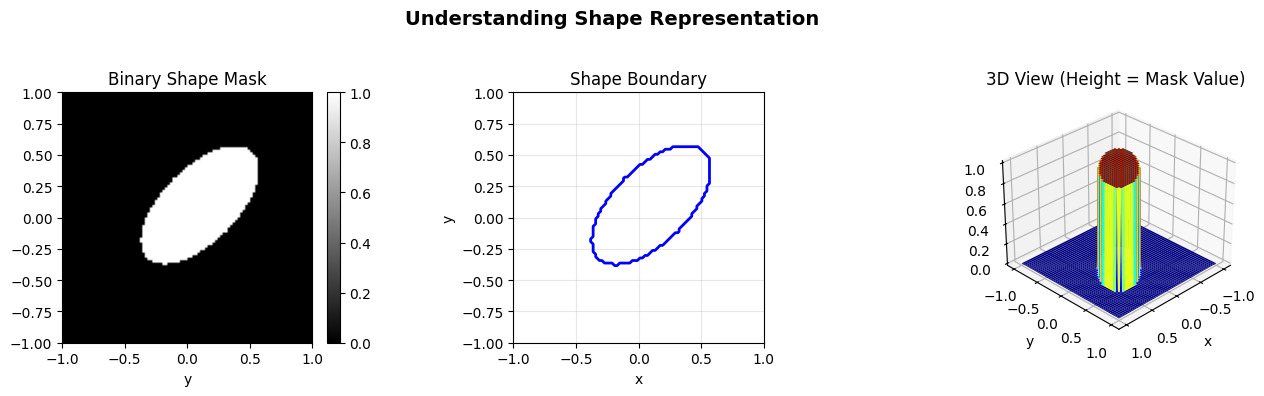

Shape parameters:
  Semi-major axis a = 0.60
  Semi-minor axis b = 0.30
  Rotation angle = 45.0 degrees
  Center = (0.10, 0.10)
  Area (pixels) = 1378
  Approx area (continuous) = 0.5624


In [8]:
print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Pixels inside shape:", int(mask.sum()))

fig = plt.figure(figsize=(14,4))

ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(
    mask.astype(float),
    extent=[x.min(), x.max(), x.min(), x.max()],
    origin="lower",
    cmap="gray"
)
ax1.set_title("Binary Shape Mask")
ax1.set_xlabel("x")
ax1.set_xlabel("y")
ax1.set_aspect("equal")
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# 2) Boundary only
ax2 = fig.add_subplot(1, 3, 2)
ax2.contour(X, Y, mask.astype(float), levels=[0.5], colors="b", linewidths=2)
ax2.set_title("Shape Boundary")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)

# 3) 3D mask
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.plot_surface(X, Y, mask.astype(float), cmap="jet", edgecolor="none")
ax3.set_title("3D View (Height = Mask Value)")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.view_init(elev=30, azim=45)

fig.suptitle("Understanding Shape Representation", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Shape parameters:")
print(f"  Semi-major axis a = {a:.2f}")
print(f"  Semi-minor axis b = {b:.2f}")
print(f"  Rotation angle = {np.degrees(theta):.1f} degrees")
print(f"  Center = ({center[0]:.2f}, {center[1]:.2f})")
print(f"  Area (pixels) = {area_pixels}")
print(f"  Approx area (continuous) = {area_continuous:.4f}")

# Notes

#### Changing a and b
Changing a and b (Semi-major/minor axis) just changes the size of the elipse as shown by the mask

#### Changing theta
This just rotates the elipse the area does change slightly because of the accuracy of the grid, but overall it just rotates

#### Changing center
This just changes where the object is centered